# 🎯 DoNext 5G — NB4_DSO1 : Prédiction Handover Binaire

**Pipeline :** NB1 ✅ → NB2 ✅ → NB3 ✅ → **NB4_DSO1**

| # | Modèle | Type |
|---|--------|------|
| M1 | XGBoost | Classique |
| M2 | LightGBM | Classique |
| M3 | Random Forest | Classique |
| M4 | BiLSTM | Deep Learning |
| M5 | TabNet (pré-entraîné) | Pré-entraîné |

---
## Section 0 — Setup & Chargement

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import json, os, gc, pickle, warnings
import pyarrow.parquet as pq
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score,
    average_precision_score, RocCurveDisplay, PrecisionRecallDisplay)
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from pytorch_tabnet.tab_model import TabNetClassifier
from pytorch_tabnet.pretraining import TabNetPretrainer
import torch

plt.rcParams.update({'figure.facecolor':'#0F1117','axes.facecolor':'#1A1D27',
    'axes.edgecolor':'#3A3D4D','axes.labelcolor':'#E0E0E0','axes.titlecolor':'#FFFFFF',
    'xtick.color':'#B0B0B0','ytick.color':'#B0B0B0','text.color':'#E0E0E0',
    'grid.color':'#2A2D3A','grid.linestyle':'--','grid.alpha':0.5,'font.family':'monospace','figure.dpi':130})

BLUE='#4FC3F7'; GREEN='#69F0AE'; ORANGE='#FFB74D'; RED='#EF5350'; PURPLE='#CE93D8'
CM_LABELS = ['No HO', 'HO']

DATASET_ROOT  = r'C:\Users\THINKPAD\Desktop\DATASET'  # ← adapter
PT_OUT_DIR    = os.path.join(DATASET_ROOT, 'PT_output')
MODEL_OUT_DIR = os.path.join(DATASET_ROOT, 'MODEL_output', 'DSO1')
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

# ── 1. Labels et index (légers) ─────────────────────────────
idx_train = np.load(os.path.join(PT_OUT_DIR,'idx_train.npy'), allow_pickle=True)
idx_val   = np.load(os.path.join(PT_OUT_DIR,'idx_val.npy'),   allow_pickle=True)
idx_test  = np.load(os.path.join(PT_OUT_DIR,'idx_test.npy'),  allow_pickle=True)
y_train   = np.load(os.path.join(PT_OUT_DIR,'y_train.npy'))
y_val     = np.load(os.path.join(PT_OUT_DIR,'y_val.npy'))
y_test    = np.load(os.path.join(PT_OUT_DIR,'y_test.npy'))
with open(os.path.join(PT_OUT_DIR,'config.json')) as f: config = json.load(f)
COLS_X = config['cols_X']

# ── 2. Chargement mémoire-safe : colonnes features seulement ─
print('Chargement du parquet (colonnes features uniquement)...')
df = pd.read_parquet(
    os.path.join(PT_OUT_DIR, 'df_preprocessed.parquet'),
    columns=COLS_X   # evite de charger les colonnes inutiles
)
gc.collect()

# ── 3. Extraction float32 + libération immédiate du df ───────
X_train = df.loc[idx_train].values.astype(np.float32); gc.collect()
X_val   = df.loc[idx_val].values.astype(np.float32);   gc.collect()
X_test  = df.loc[idx_test].values.astype(np.float32)
del df; gc.collect()  # libere la RAM immediatement

ratio = int((1-y_train.mean()) / max(y_train.mean(), 1e-6))
print(f'✅ X_train {X_train.shape} | HO%={y_train.mean()*100:.2f}% | ratio 1:{ratio}')


Chargement du parquet (colonnes features uniquement)...
✅ X_train (8822003, 104) | HO%=4.08% | ratio 1:23


---
## Section 1 — M1 : XGBoost

In [2]:
print('='*60+'\n  M1 — XGBoost\n'+'='*60)
xgb_model = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=ratio,
    eval_metric='aucpr', early_stopping_rounds=30, tree_method='hist',
    random_state=42, n_jobs=-1, use_label_encoder=False)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=50)
print(f'✅ best_iteration={xgb_model.best_iteration}')

  M1 — XGBoost
[0]	validation_0-aucpr:0.91351
[50]	validation_0-aucpr:0.95713
[100]	validation_0-aucpr:0.96046
[150]	validation_0-aucpr:0.96406
[200]	validation_0-aucpr:0.96631
[250]	validation_0-aucpr:0.96723
[300]	validation_0-aucpr:0.96770
[303]	validation_0-aucpr:0.96778
✅ best_iteration=273


In [3]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_xgb, target_names=CM_LABELS))
metrics_xgb = {'model':'XGBoost','f1':round(f1_score(y_test,y_pred_xgb),4),
    'precision':round(precision_score(y_test,y_pred_xgb),4),
    'recall':round(recall_score(y_test,y_pred_xgb),4),
    'auc_roc':round(roc_auc_score(y_test,y_prob_xgb),4),
    'auc_pr':round(average_precision_score(y_test,y_prob_xgb),4)}
with open(os.path.join(MODEL_OUT_DIR,'xgb_model.pkl'),'wb') as f: pickle.dump(xgb_model,f)

              precision    recall  f1-score   support

       No HO       1.00      0.89      0.94   1458781
          HO       0.73      0.99      0.84    431651

    accuracy                           0.91   1890432
   macro avg       0.86      0.94      0.89   1890432
weighted avg       0.94      0.91      0.92   1890432



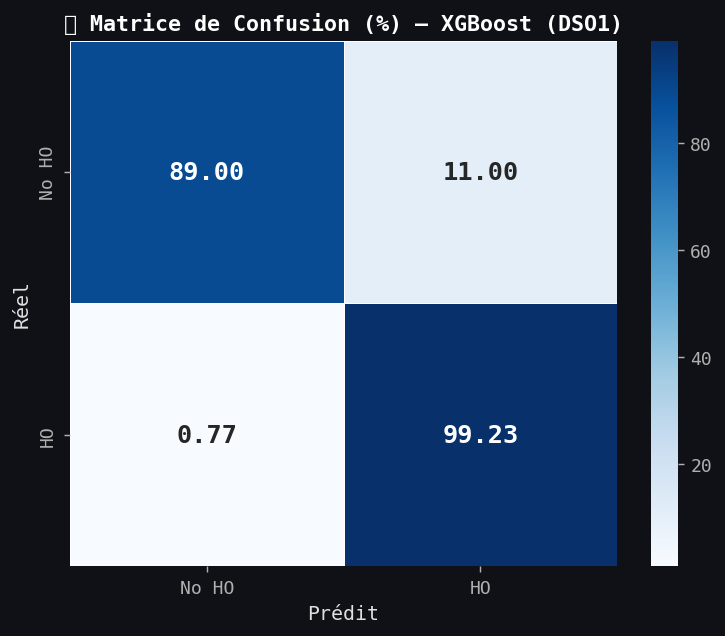


=== POURCENTAGES ===
VN: 89.00% | FP: 11.00%
FN: 0.77% | VP: 99.23%


In [4]:
# ── Matrice de Confusion (%) — XGBoost ───────────────────────

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Normalisation en %
cm_pct = cm_xgb.astype('float') / cm_xgb.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm_pct * 100,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=CM_LABELS,
    yticklabels=CM_LABELS,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size':14,'weight':'bold'}
)

ax.set_xlabel('Prédit', fontsize=11)
ax.set_ylabel('Réel', fontsize=11)
ax.set_title('📊 Matrice de Confusion (%) — XGBoost (DSO1)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_OUT_DIR,'cm_xgb_dso1_pct.png'),
    bbox_inches='tight',
    facecolor='#0F1117'
)

plt.show()

# affichage clair
print("\n=== POURCENTAGES ===")
print(f"VN: {cm_pct[0,0]*100:.2f}% | FP: {cm_pct[0,1]*100:.2f}%")
print(f"FN: {cm_pct[1,0]*100:.2f}% | VP: {cm_pct[1,1]*100:.2f}%")

---
## Section 2 — M2 : LightGBM

In [5]:
print('='*60+'\n  M2 — LightGBM\n'+'='*60)
lgbm_model = LGBMClassifier(n_estimators=500, max_depth=7, learning_rate=0.05, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, is_unbalance=True,
    metric='average_precision', random_state=42, n_jobs=-1, verbose=-1)
lgbm_model.fit(X_train, y_train, eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30,verbose=False), lgb.log_evaluation(50)])
print('✅ LightGBM entraîné')

  M2 — LightGBM
[50]	valid_0's average_precision: 0.959781
[100]	valid_0's average_precision: 0.964061
[150]	valid_0's average_precision: 0.966551
[200]	valid_0's average_precision: 0.968099
[250]	valid_0's average_precision: 0.969531
[300]	valid_0's average_precision: 0.970465
[350]	valid_0's average_precision: 0.971076
[400]	valid_0's average_precision: 0.971603
[450]	valid_0's average_precision: 0.971603
✅ LightGBM entraîné


In [6]:
y_pred_lgbm = lgbm_model.predict(X_test)
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_lgbm, target_names=CM_LABELS))
metrics_lgbm = {'model':'LightGBM','f1':round(f1_score(y_test,y_pred_lgbm),4),
    'precision':round(precision_score(y_test,y_pred_lgbm),4),
    'recall':round(recall_score(y_test,y_pred_lgbm),4),
    'auc_roc':round(roc_auc_score(y_test,y_prob_lgbm),4),
    'auc_pr':round(average_precision_score(y_test,y_prob_lgbm),4)}
with open(os.path.join(MODEL_OUT_DIR,'lgbm_model.pkl'),'wb') as f: pickle.dump(lgbm_model,f)

              precision    recall  f1-score   support

       No HO       1.00      0.90      0.94   1458781
          HO       0.74      0.99      0.85    431651

    accuracy                           0.92   1890432
   macro avg       0.87      0.94      0.90   1890432
weighted avg       0.94      0.92      0.92   1890432



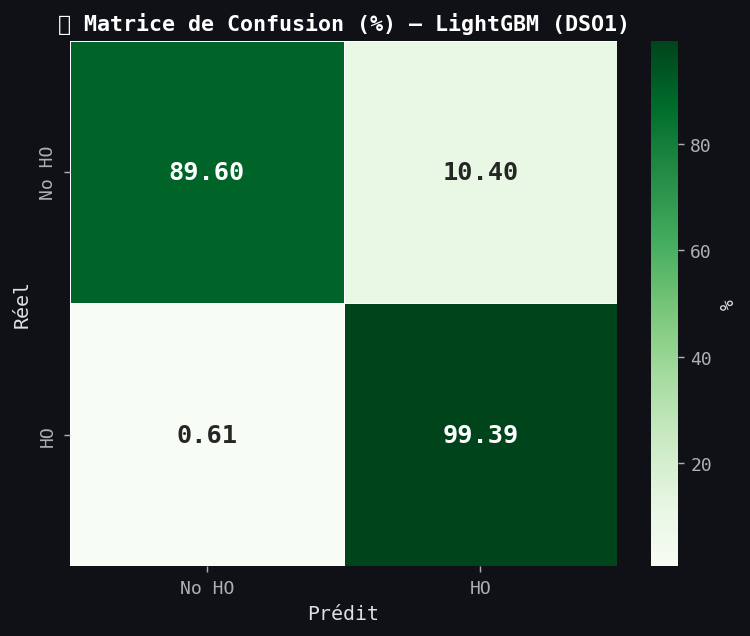


=== POURCENTAGES ===
VN: 89.60% | FP: 10.40%
FN: 0.61% | VP: 99.39%


In [9]:
# ── Matrice de Confusion (%) — LightGBM ─────────────────────

cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

# Normalisation par ligne (réel)
cm_pct = cm_lgbm.astype('float') / cm_lgbm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm_pct * 100,
    annot=True,
    fmt='.2f',
    cmap='Greens',
    xticklabels=CM_LABELS,
    yticklabels=CM_LABELS,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size':14,'weight':'bold'},
    cbar_kws={'label': '%'}
)

ax.set_xlabel('Prédit', fontsize=11)
ax.set_ylabel('Réel', fontsize=11)
ax.set_title('📊 Matrice de Confusion (%) — LightGBM (DSO1)', fontsize=12, fontweight='bold')

plt.tight_layout()

plt.savefig(
    os.path.join(MODEL_OUT_DIR,'cm_lgbm_dso1_pct.png'),
    bbox_inches='tight',
    facecolor='#0F1117'
)

plt.show()

# Affichage clair
print("\n=== POURCENTAGES ===")
print(f"VN: {cm_pct[0,0]*100:.2f}% | FP: {cm_pct[0,1]*100:.2f}%")
print(f"FN: {cm_pct[1,0]*100:.2f}% | VP: {cm_pct[1,1]*100:.2f}%")

---
## Section 3 — M3 : Random Forest

In [7]:
print('='*60+'\n  M3 — Random Forest\n'+'='*60)
rf_model = RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_leaf=20,
    max_features='sqrt', class_weight='balanced_subsample',
    max_samples=0.2, random_state=42, n_jobs=-1, verbose=1)
rf_model.fit(X_train, y_train)
print('✅ Random Forest entraîné')

  M3 — Random Forest


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   30.0s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:  5.3min


✅ Random Forest entraîné


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  9.4min finished


In [8]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_rf, target_names=CM_LABELS))
metrics_rf = {'model':'Random Forest','f1':round(f1_score(y_test,y_pred_rf),4),
    'precision':round(precision_score(y_test,y_pred_rf),4),
    'recall':round(recall_score(y_test,y_pred_rf),4),
    'auc_roc':round(roc_auc_score(y_test,y_prob_rf),4),
    'auc_pr':round(average_precision_score(y_test,y_prob_rf),4)}
with open(os.path.join(MODEL_OUT_DIR,'rf_model.pkl'),'wb') as f: pickle.dump(rf_model,f)

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    2.8s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    5.5s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.4s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    3.8s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    6.5s finished


              precision    recall  f1-score   support

       No HO       0.92      0.93      0.93   1458781
          HO       0.76      0.74      0.75    431651

    accuracy                           0.89   1890432
   macro avg       0.84      0.83      0.84   1890432
weighted avg       0.89      0.89      0.89   1890432



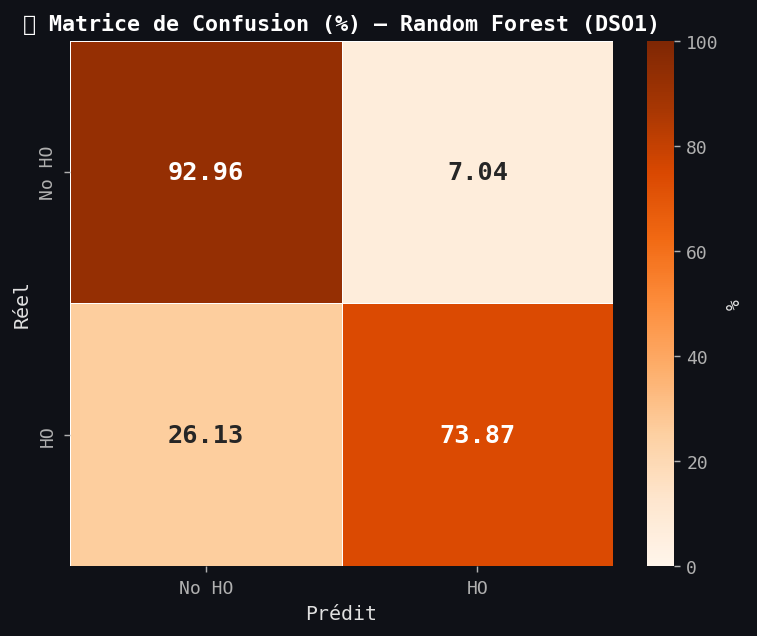


=== POURCENTAGES ===
VN: 92.96% | FP: 7.04%
FN: 26.13% | VP: 73.87%


In [9]:
# ── Matrice de Confusion (%) — Random Forest ────────────────

cm_rf = confusion_matrix(y_test, y_pred_rf)

# Normalisation par ligne (réel)
cm_pct = cm_rf.astype('float') / cm_rf.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm_pct * 100,
    annot=True,
    fmt='.2f',
    cmap='Oranges',
    xticklabels=CM_LABELS,
    yticklabels=CM_LABELS,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size':14,'weight':'bold'},
    cbar_kws={'label': '%'},
    vmin=0, vmax=100
)

ax.set_xlabel('Prédit', fontsize=11)
ax.set_ylabel('Réel', fontsize=11)
ax.set_title('📊 Matrice de Confusion (%) — Random Forest (DSO1)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_OUT_DIR,'cm_rf_dso1_pct.png'),
    bbox_inches='tight',
    facecolor='#0F1117'
)
plt.show()

print('\n=== POURCENTAGES ===')
print(f'VN: {cm_pct[0,0]*100:.2f}% | FP: {cm_pct[0,1]*100:.2f}%')
print(f'FN: {cm_pct[1,0]*100:.2f}% | VP: {cm_pct[1,1]*100:.2f}%')


---
## Section 4 — M4 : BiLSTM (Deep Learning)

In [10]:
print('='*60+'\n  M4 — BiLSTM\n'+'='*60)
WINDOW_COLS = [c for c in COLS_X if any(f'_t-{k}' in c for k in range(1,6))]
T = 5 if WINDOW_COLS else 1
if WINDOW_COLS:
    w_idx = [list(COLS_X).index(c) for c in WINDOW_COLS]
    F = len(w_idx)//T
    X_tr_3d=X_train[:,w_idx].reshape(-1,T,F); X_va_3d=X_val[:,w_idx].reshape(-1,T,F); X_te_3d=X_test[:,w_idx].reshape(-1,T,F)
else:
    F=X_train.shape[1]; T=1
    X_tr_3d=X_train.reshape(-1,1,F); X_va_3d=X_val.reshape(-1,1,F); X_te_3d=X_test.reshape(-1,1,F)

tf.random.set_seed(42)
inp = Input(shape=(T,F))
x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2))(inp)
x = BatchNormalization()(x)
x = Bidirectional(LSTM(64, return_sequences=False, dropout=0.2))(x)
x = BatchNormalization()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
out = Dense(1, activation='sigmoid')(x)
lstm_model = Model(inputs=inp, outputs=out, name='BiLSTM_DSO1')
lstm_model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['AUC'])
sw = np.where(y_train==1, ratio, 1).astype(np.float32)
history = lstm_model.fit(X_tr_3d, y_train, validation_data=(X_va_3d, y_val), sample_weight=sw,
    epochs=30, batch_size=2048, verbose=1,
    callbacks=[EarlyStopping(monitor='val_AUC',patience=5,restore_best_weights=True,mode='max'),
               ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3,min_lr=1e-6),
               ModelCheckpoint(os.path.join(MODEL_OUT_DIR,'lstm_best.h5'),monitor='val_AUC',save_best_only=True,mode='max')])
print('✅ LSTM entraîné')

  M4 — BiLSTM
Epoch 1/30
4308/4308 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - AUC: 0.5018 - loss: 1.3315  

4308/4308 ━━━━━━━━━━━━━━━━━━━━ 185s 41ms/step - AUC: 0.5018 - loss: 1.3188 - val_AUC: 0.5000 - val_loss: 0.6840 - learning_rate: 0.0010
Epoch 2/30
4308/4308 ━━━━━━━━━━━━━━━━━━━━ 201s 41ms/step - AUC: 0.5003 - loss: 1.3152 - val_AUC: 0.5000 - val_loss: 0.6849 - learning_rate: 0.0010
Epoch 3/30
4308/4308 ━━━━━━━━━━━━━━━━━━━━ 205s 42ms/step - AUC: 0.5008 - loss: 1.3151 - val_AUC: 0.5000 - val_loss: 0.6847 - learning_rate: 0.0010
Epoch 4/30
4308/4308 ━━━━━━━━━━━━━━━━━━━━ 199s 41ms/step - AUC: 0.5010 - loss: 1.3150 - val_AUC: 0.5000 - val_loss: 0.6891 - learning_rate: 0.0010
Epoch 5/30
4308/4308 ━━━━━━━━━━━━━━━━━━━━ 184s 43ms/step - AUC: 0.5010 - loss: 1.3148 - val_AUC: 0.5000 - val_loss: 0.6852 - learning_rate: 5.0000e-04
Epoch 6/30
4308/4308 ━━━━━━━━━━━━━━━━━━━━ 195s 41ms/step - AUC: 0.5012 - loss: 1.3145 - val_AUC: 0.5000 - val_loss: 0.6853 - learning_rate: 5.0000e-04
✅ LSTM entraîné


In [11]:
y_prob_lstm = lstm_model.predict(X_te_3d, batch_size=4096, verbose=0).flatten()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)
print(classification_report(y_test, y_pred_lstm, target_names=CM_LABELS))
metrics_lstm = {'model':'BiLSTM','f1':round(f1_score(y_test,y_pred_lstm),4),
    'precision':round(precision_score(y_test,y_pred_lstm),4),
    'recall':round(recall_score(y_test,y_pred_lstm),4),
    'auc_roc':round(roc_auc_score(y_test,y_prob_lstm),4),
    'auc_pr':round(average_precision_score(y_test,y_prob_lstm),4)}
lstm_model.save(os.path.join(MODEL_OUT_DIR,'lstm_model.h5'))

              precision    recall  f1-score   support

       No HO       0.77      1.00      0.87   1458781
          HO       0.00      0.00      0.00    431651

    accuracy                           0.77   1890432
   macro avg       0.39      0.50      0.44   1890432
weighted avg       0.60      0.77      0.67   1890432



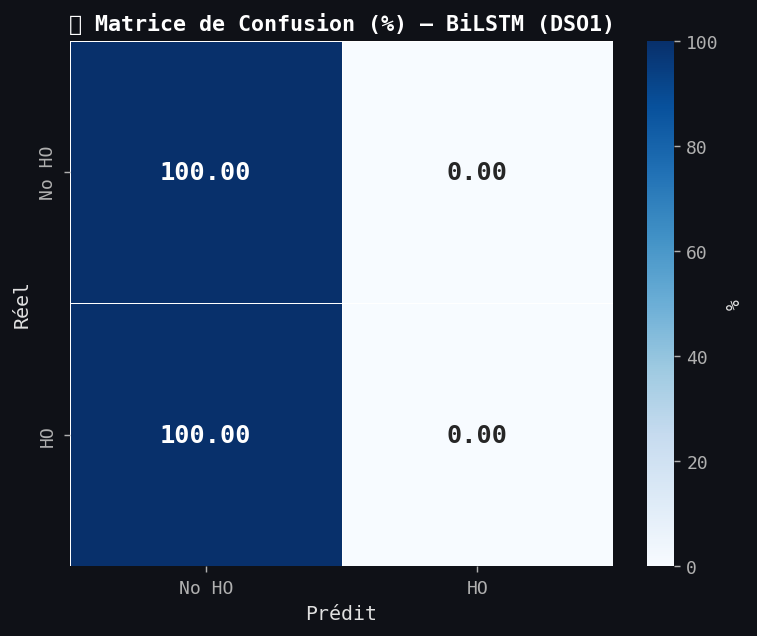


=== POURCENTAGES ===
VN: 100.00% | FP: 0.00%
FN: 100.00% | VP: 0.00%


In [12]:
# ── Matrice de Confusion (%) — BiLSTM ───────────────────────

cm_lstm = confusion_matrix(y_test, y_pred_lstm)

# Normalisation par ligne (réel)
cm_pct = cm_lstm.astype('float') / cm_lstm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm_pct * 100,
    annot=True,
    fmt='.2f',
    cmap='Blues',  # 🔥 changé en bleu
    xticklabels=CM_LABELS,
    yticklabels=CM_LABELS,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size':14,'weight':'bold'},
    cbar_kws={'label': '%'}
)

ax.set_xlabel('Prédit', fontsize=11)
ax.set_ylabel('Réel', fontsize=11)
ax.set_title('📊 Matrice de Confusion (%) — BiLSTM (DSO1)', fontsize=12, fontweight='bold')

plt.tight_layout()

plt.savefig(
    os.path.join(MODEL_OUT_DIR,'cm_lstm_dso1_pct.png'),
    bbox_inches='tight',
    facecolor='#0F1117'
)

plt.show()

# Affichage clair
print("\n=== POURCENTAGES ===")
print(f"VN: {cm_pct[0,0]*100:.2f}% | FP: {cm_pct[0,1]*100:.2f}%")
print(f"FN: {cm_pct[1,0]*100:.2f}% | VP: {cm_pct[1,1]*100:.2f}%")

---
## Section 5 — M5 : TabNet (Pré-entraîné)

In [14]:
pip show pytorch-tabnet

Name: pytorch-tabnetNote: you may need to restart the kernel to use updated packages.

Version: 4.1.0
Summary: PyTorch implementation of TabNet
Home-page: https://github.com/dreamquark-ai/tabnet
Author: 
Author-email: 
License: 
Location: C:\Users\THINKPAD\anaconda3\Lib\site-packages
Requires: numpy, scikit_learn, scipy, torch, tqdm
Required-by: 


In [3]:
print('='*60+'\n  M5 — TabNet\n'+'='*60)

# ── 1. Sampling ─────────────────────────────────────────────
N_TN = 300_000
idx_sample = np.random.choice(len(X_train), N_TN, replace=False)
X_tr_tn    = X_train[idx_sample]
X_va_tn    = X_val.copy()
X_te_tn    = X_test.copy()
y_train_tn = y_train[idx_sample]
print(f'Sample train : {len(X_tr_tn)}')

# ── 2. Modèle final ─────────────────────────────────────────
tabnet_model = TabNetClassifier(
    n_d=16, n_a=16, n_steps=3, gamma=1.5,
    n_independent=2, n_shared=2, mask_type='entmax',
    optimizer_fn=torch.optim.Adam,
    optimizer_params={'lr': 2e-3},
    verbose=0, seed=42
)

# ✅ Mini-fit pour forcer l'initialisation du réseau interne
tabnet_model.fit(
    X_train=X_tr_tn[:512],
    y_train=y_train_tn[:512].astype(int),
    max_epochs=1,
    batch_size=512,
    virtual_batch_size=512
)

# ✅ Transfert des poids du pretrainer (réseau maintenant initialisé)
tabnet_model.load_weights_from_unsupervised(pretrainer)

# ── 3. Entraînement supervisé réel ──────────────────────────
tabnet_model.verbose = 10
tabnet_model.fit(
    X_train=X_tr_tn,
    y_train=y_train_tn.astype(int),
    eval_set=[(X_va_tn, y_val.astype(int))],
    eval_metric=['auc'],
    max_epochs=30, patience=5,
    batch_size=4096, virtual_batch_size=512,
    weights=1
)
print('✅ TabNet entraîné')

  M5 — TabNet
Sample train : 300000


NameError: name 'pretrainer' is not defined

In [17]:
y_pred_tn = tabnet_model.predict(X_te_tn)
y_prob_tn = tabnet_model.predict_proba(X_te_tn)[:,1]
print(classification_report(y_test, y_pred_tn, target_names=CM_LABELS))
metrics_tn = {'model':'TabNet','f1':round(f1_score(y_test,y_pred_tn),4),
    'precision':round(precision_score(y_test,y_pred_tn),4),
    'recall':round(recall_score(y_test,y_pred_tn),4),
    'auc_roc':round(roc_auc_score(y_test,y_prob_tn),4),
    'auc_pr':round(average_precision_score(y_test,y_prob_tn),4)}
tabnet_model.save_model(os.path.join(MODEL_OUT_DIR,'tabnet_model'))

              precision    recall  f1-score   support

       No HO       0.99      0.86      0.92   1458781
          HO       0.67      0.98      0.80    431651

    accuracy                           0.89   1890432
   macro avg       0.83      0.92      0.86   1890432
weighted avg       0.92      0.89      0.89   1890432

Successfully saved model at C:\Users\THINKPAD\Desktop\DATASET\MODEL_output\DSO1\tabnet_model.zip


'C:\\Users\\THINKPAD\\Desktop\\DATASET\\MODEL_output\\DSO1\\tabnet_model.zip'

In [2]:
# ── Matrice de Confusion (%) — TabNet ───────────────────────

cm_tn = confusion_matrix(y_test, y_pred_tn)

# Normalisation par ligne (réel)
cm_pct = cm_tn.astype('float') / cm_tn.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm_pct * 100,
    annot=True,
    fmt='.2f',
    cmap='Blues',  # 🔥 uniforme avec tous les modèles
    xticklabels=CM_LABELS,
    yticklabels=CM_LABELS,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size':14,'weight':'bold'},
    cbar_kws={'label': '%'},
    vmin=0, vmax=100  # 🔥 même échelle pour tous les modèles
)

ax.set_xlabel('Prédit', fontsize=11)
ax.set_ylabel('Réel', fontsize=11)
ax.set_title('📊 Matrice de Confusion (%) — TabNet (DSO1)', fontsize=12, fontweight='bold')

plt.tight_layout()

plt.savefig(
    os.path.join(MODEL_OUT_DIR,'cm_tabnet_dso1_pct.png'),
    bbox_inches='tight',
    facecolor='#0F1117'
)

plt.show()

# Affichage clair
print("\n=== POURCENTAGES ===")
print(f"VN: {cm_pct[0,0]*100:.2f}% | FP: {cm_pct[0,1]*100:.2f}%")
print(f"FN: {cm_pct[1,0]*100:.2f}% | VP: {cm_pct[1,1]*100:.2f}%")

NameError: name 'y_pred_tn' is not defined

---
## Section 6 — Grille comparative : toutes les matrices

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(28, 5))
models_cm = [('XGBoost',cm_xgb,'Blues'),('LightGBM',cm_lgbm,'Greens'),
             ('Random Forest',cm_rf,'Oranges'),('BiLSTM',cm_lstm,'Reds'),('TabNet',cm_tn,'Purples')]
for ax, (name, cm, cmap) in zip(axes, models_cm):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
        xticklabels=CM_LABELS, yticklabels=CM_LABELS,
        linewidths=0.5, ax=ax, annot_kws={'size':13,'weight':'bold'}, cbar=False)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
plt.suptitle('🔢 Toutes les Matrices de Confusion — DSO1', fontsize=14, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_all_dso1.png'), bbox_inches='tight', facecolor='#0F1117')
plt.show()

---
## Section 7 — Comparaison finale

In [ ]:
all_metrics = [metrics_xgb, metrics_lgbm, metrics_rf, metrics_lstm, metrics_tn]
df_results = pd.DataFrame(all_metrics).set_index('model')
print(df_results.to_string())
best = df_results['f1'].idxmax()
print(f'\n🏆 Meilleur (F1) : {best} → {df_results.loc[best,"f1"]:.4f}')
with open(os.path.join(MODEL_OUT_DIR,'results_dso1.json'),'w') as f: json.dump(all_metrics,f,indent=2)

models_list = ['XGBoost','LightGBM','Random Forest','BiLSTM','TabNet']
probs_list  = [y_prob_xgb, y_prob_lgbm, y_prob_rf, y_prob_lstm, y_prob_tn]
colors_list = [BLUE,GREEN,ORANGE,RED,PURPLE]
fig, axes = plt.subplots(1, 2, figsize=(16,6))
for name,prob,color in zip(models_list,probs_list,colors_list):
    RocCurveDisplay.from_predictions(y_test,prob,name=name,ax=axes[0],color=color)
axes[0].set_title('Courbes ROC',fontweight='bold'); axes[0].plot([0,1],[0,1],'--',color='gray',lw=0.8)
for name,prob,color in zip(models_list,probs_list,colors_list):
    PrecisionRecallDisplay.from_predictions(y_test,prob,name=name,ax=axes[1],color=color)
axes[1].set_title('Precision-Recall',fontweight='bold')
plt.suptitle('🏆 DSO1 — Dashboard Final',fontsize=14,fontweight='bold',color='white')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'dashboard_dso1.png'),bbox_inches='tight',facecolor='#0F1117')
plt.show()